# XGBoost Long-Short Strategy — Presentation

**Strategy: C · Rank-weight VW + Leg Balance (half-life 120m)**

- Model: XGBoost trained on 200+ JKP cross-sectional characteristics
- Training: expanding window (no look-ahead), exponential sample weights (hl = 120 months)
- Portfolio: conviction-weighted (rank), value-weight capped, long-short decile spread
- Leg balance: inverse-vol scaling so long and short books have equal notional risk
- Transaction cost: 10 bps one-way

Benchmarks: **US Market VW** and **US Market EW** (local returns, JKP dataset)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

ROOT  = Path("../data/backtest")
BENCH = ROOT / "benchmark"

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

STRAT_COLOR = "steelblue"
VW_COLOR    = "dimgray"
EW_COLOR    = "darkorange"

In [2]:
C = pd.read_csv(
    ROOT / "xgboost_ab_hl120" / "monthly_returns_C_rankw_vw_balanced.csv",
    parse_dates=["eom"]
).set_index("eom").sort_index()

MKT = pd.read_csv(
    BENCH / "monthly_returns.csv", parse_dates=["eom"]
).set_index("eom").sort_index()

# align all series to the strategy's date range
idx  = C.index
strat = C["net_qspread"].reindex(idx)
vw    = MKT["mkt_vw_lcl"].reindex(idx)
ew    = MKT["mkt_ew_lcl"].reindex(idx)

print(f"Strategy: {idx[0].date()} → {idx[-1].date()}  ({len(idx)} months)")
print(f"Benchmark rows available: {len(MKT)}")

Strategy: 1986-01-31 → 2025-10-31  (478 months)
Benchmark rows available: 479


## 1 · Performance Summary

In [3]:
def perf(s, label):
    s = s.dropna()
    ann_ret = s.mean() * 12
    ann_vol = s.std()  * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum     = (1 + s).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar  = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    skew    = float(s.skew())
    win_rt  = (s > 0).mean()
    return {
        "label": label, "Ann. Return": ann_ret, "Ann. Vol": ann_vol,
        "Sharpe": sharpe, "Max DD": max_dd, "Calmar": calmar,
        "Win Rate": win_rt, "Skew": skew, "N": len(s),
    }

rows = [
    perf(strat, "Strategy (C hl120)"),
    perf(vw,    "Market VW"),
    perf(ew,    "Market EW"),
]
tbl = pd.DataFrame(rows).set_index("label")
out = tbl.copy()
for c in ["Ann. Return", "Ann. Vol", "Max DD", "Win Rate"]:
    out[c] = out[c].map("{:.2%}".format)
for c in ["Sharpe", "Skew"]:
    out[c] = out[c].map("{:.3f}".format)
out["Calmar"] = out["Calmar"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
out["N"]      = out["N"].map("{:.0f}".format)
print("Full-sample performance (net of 10 bps TC)\n")
print(out.to_string())

Full-sample performance (net of 10 bps TC)

                   Ann. Return Ann. Vol Sharpe   Max DD Calmar Win Rate    Skew    N
label                                                                               
Strategy (C hl120)      10.21%   14.15%  0.722  -30.50%   0.33   56.90%   0.691  478
Market VW               12.54%   15.65%  0.801  -50.19%   0.25   65.90%  -0.633  478
Market EW               17.16%   17.72%  0.968  -50.32%   0.34   66.95%  -0.707  478


## 2 · Cumulative Returns

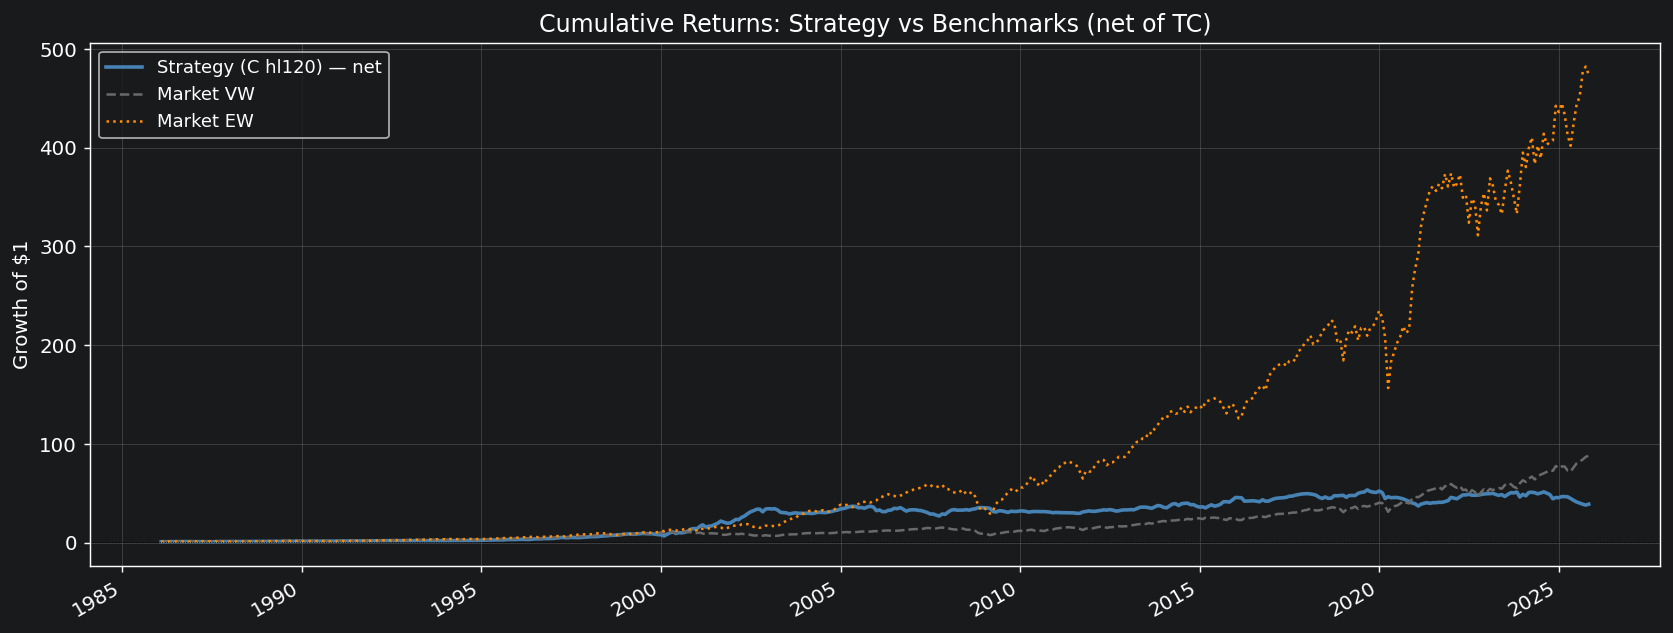

In [4]:
def cum(s): return (1 + s.dropna()).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cum(strat), label="Strategy (C hl120) — net", lw=2.0, color=STRAT_COLOR)
ax.plot(cum(vw),    label="Market VW",                lw=1.4, color=VW_COLOR,  ls="--")
ax.plot(cum(ew),    label="Market EW",                lw=1.4, color=EW_COLOR,  ls=":")
ax.axhline(1, color="black", lw=0.5, ls=":")
ax.set_ylabel("Growth of $1")
ax.set_title("Cumulative Returns: Strategy vs Benchmarks (net of TC)")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 3 · Sub-period Sharpe

In [5]:
def sharpe(s): return s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else np.nan

def subperiod_tbl(series_dict):
    all_years = sorted({(y // 10) * 10 for s in series_dict.values() for y in s.dropna().index.year})
    rows = []
    for dec in all_years:
        row = {"Period": f"{dec}s"}
        for label, s in series_dict.items():
            sub = s[(s.index.year >= dec) & (s.index.year < dec + 10)].dropna()
            row[label] = sharpe(sub) if len(sub) >= 6 else np.nan
        rows.append(row)
    for w, tag in [(60, "Last 5y"), (120, "Last 10y")]:
        row = {"Period": tag}
        for label, s in series_dict.items():
            sub = s.dropna().iloc[-w:]
            row[label] = sharpe(sub)
        rows.append(row)
    row = {"Period": "FULL"}
    for label, s in series_dict.items():
        row[label] = sharpe(s.dropna())
    rows.append(row)
    return pd.DataFrame(rows).set_index("Period")

sp = subperiod_tbl({
    "Strategy": strat,
    "Mkt VW":   vw,
    "Mkt EW":   ew,
})
print("Sharpe by decade and trailing window\n")
print(sp.round(3).to_string())

Sharpe by decade and trailing window

          Strategy  Mkt VW  Mkt EW
Period                            
1980s        0.818   0.917   0.751
1990s        1.544   1.328   1.410
2000s        0.775   0.170   0.895
2010s        0.594   1.014   1.060
2020s       -0.356   0.849   0.656
Last 5y     -0.064   1.100   0.934
Last 10y     0.007   0.911   0.740
FULL         0.722   0.801   0.968


## 4 · Drawdown

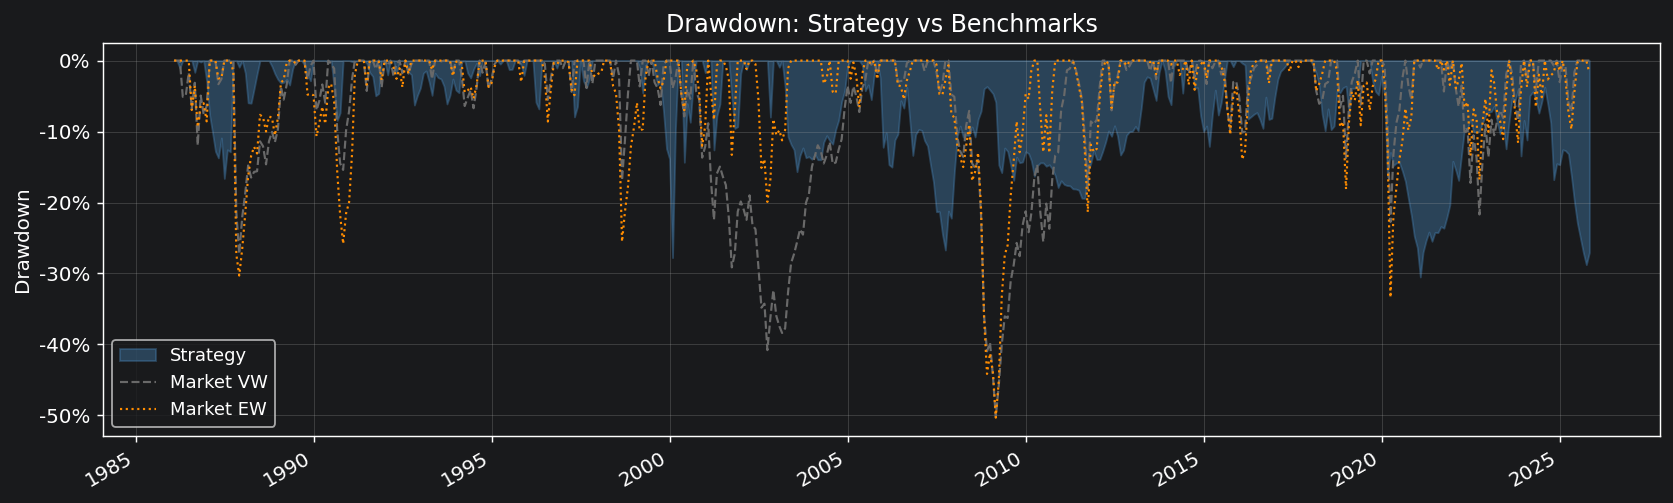

In [6]:
def drawdown(s):
    c = (1 + s.dropna()).cumprod()
    return (c - c.cummax()) / c.cummax()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(drawdown(strat).index, drawdown(strat), alpha=0.40, color=STRAT_COLOR, label="Strategy")
ax.plot(drawdown(vw),  color=VW_COLOR,  lw=1.2, ls="--", label="Market VW")
ax.plot(drawdown(ew),  color=EW_COLOR,  lw=1.2, ls=":",  label="Market EW")
ax.set_ylabel("Drawdown")
ax.set_title("Drawdown: Strategy vs Benchmarks")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 5 · Rolling 12-Month Sharpe

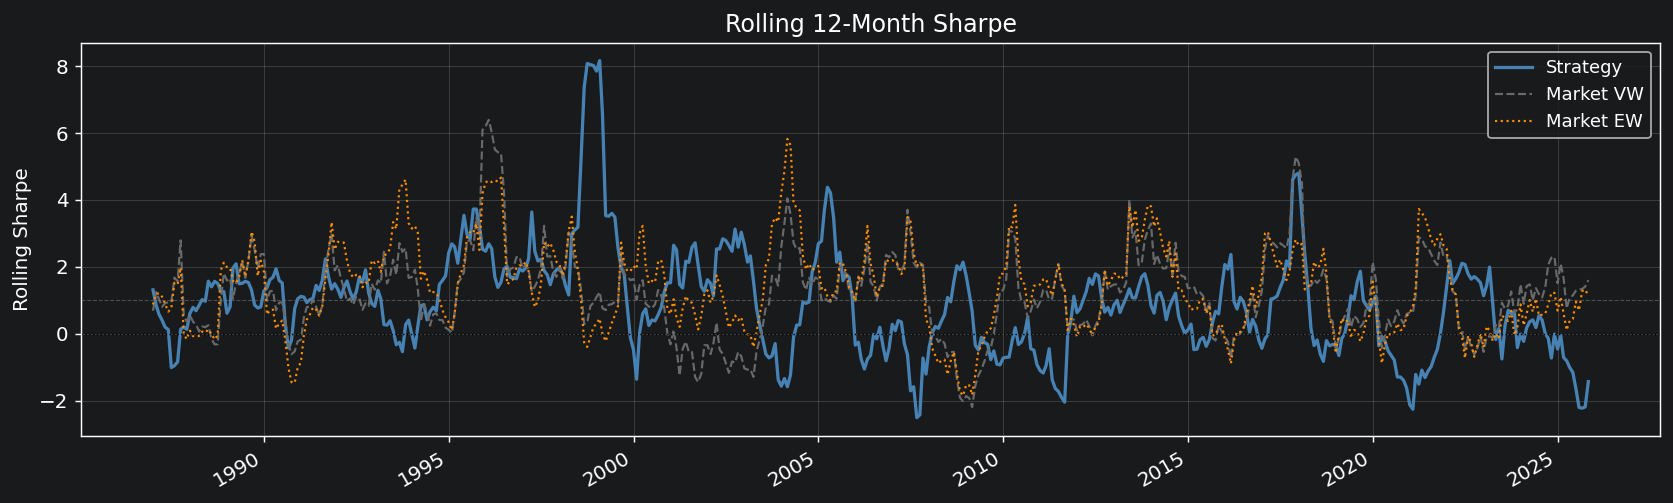

In [7]:
def rolling_sr(s, w=12):
    r = s.rolling(w)
    std = r.std()
    return np.where(std > 0, r.mean() / std * np.sqrt(12), np.nan)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(strat.index, rolling_sr(strat), label="Strategy", lw=1.8, color=STRAT_COLOR)
ax.plot(vw.index,    rolling_sr(vw),    label="Market VW", lw=1.2, color=VW_COLOR,  ls="--")
ax.plot(ew.index,    rolling_sr(ew),    label="Market EW", lw=1.2, color=EW_COLOR,  ls=":")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.axhline(1, color="gray",  lw=0.6, ls="--", alpha=0.5)
ax.set_ylabel("Rolling Sharpe")
ax.set_title("Rolling 12-Month Sharpe")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 6 · Market Neutrality (CAPM Alpha)

In [8]:
def capm_alpha(strategy_ret, market_ret, label):
    df = pd.concat([strategy_ret.rename("strat"), market_ret.rename("mkt")], axis=1).dropna()
    slope, intercept, r, p, _ = stats.linregress(df["mkt"], df["strat"])
    n = len(df)
    residuals = df["strat"] - (intercept + slope * df["mkt"])
    s2    = residuals.var(ddof=2)
    x_bar = df["mkt"].mean()
    sxx   = ((df["mkt"] - x_bar) ** 2).sum()
    se_int = np.sqrt(s2 * (1/n + x_bar**2 / sxx))
    t_a   = intercept / se_int
    p_a   = 2 * stats.t.sf(abs(t_a), df=n - 2)
    return {"Benchmark": label, "Alpha (ann.)": intercept * 12,
            "Beta": slope, "t(alpha)": t_a, "p(alpha)": p_a, "R²": r**2, "N": n}

res = pd.DataFrame([
    capm_alpha(strat, vw, "vs Market VW"),
    capm_alpha(strat, ew, "vs Market EW"),
]).set_index("Benchmark")

out = res.copy()
out["Alpha (ann.)"] = out["Alpha (ann.)"].map("{:.2%}".format)
out["Beta"]         = out["Beta"].map("{:.4f}".format)
out["t(alpha)"]     = out["t(alpha)"].map("{:.2f}".format)
out["p(alpha)"]     = out["p(alpha)"].map("{:.4f}".format)
out["R²"]           = out["R²"].map("{:.4f}".format)
out["N"]            = out["N"].map("{:.0f}".format)
print("CAPM Alpha (strategy net return regressed on benchmark)\n")
print(out.to_string())
print("\nBeta ≈ 0 → market-neutral spread. |t| > 2 → alpha significant at 5%.")

CAPM Alpha (strategy net return regressed on benchmark)

             Alpha (ann.)     Beta t(alpha) p(alpha)      R²    N
Benchmark                                                        
vs Market VW       10.70%  -0.0390     4.65   0.0000  0.0019  478
vs Market EW       10.57%  -0.0211     4.54   0.0000  0.0007  478

Beta ≈ 0 → market-neutral spread. |t| > 2 → alpha significant at 5%.


## 7 · Information Coefficient (Signal Quality)

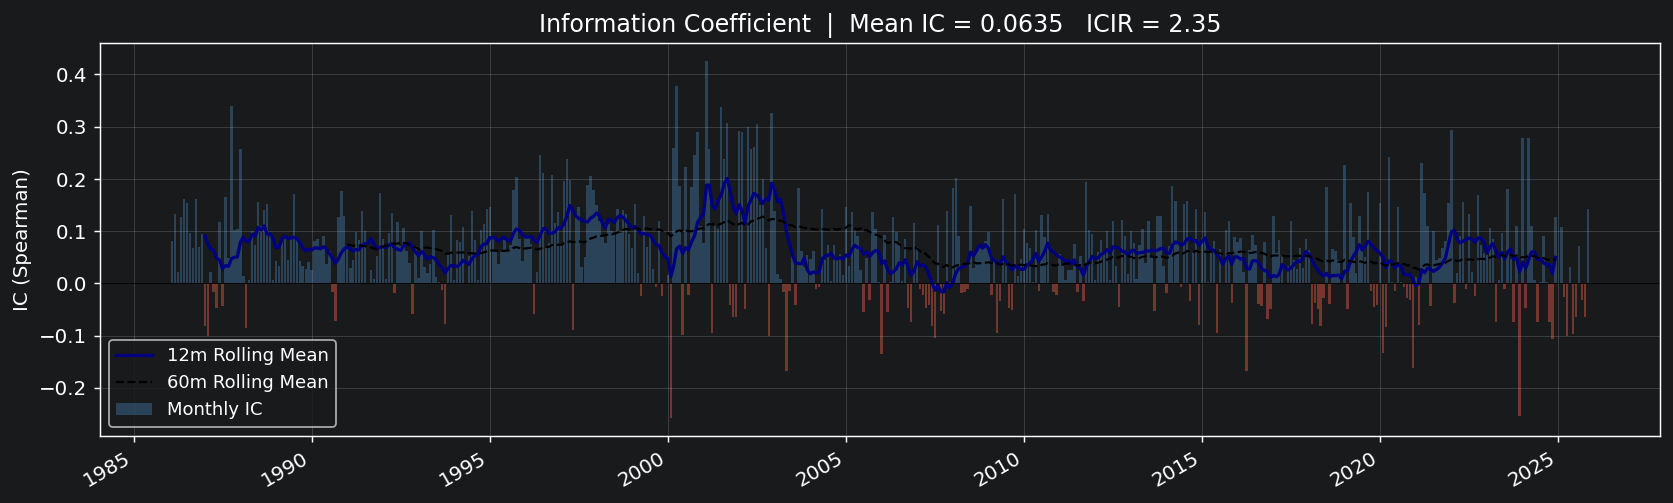

In [9]:
ic = C["ic_spearman"]

fig, ax = plt.subplots(figsize=(13, 4))
colors = [STRAT_COLOR if v >= 0 else "tomato" for v in ic.fillna(0)]
ax.bar(ic.index, ic, width=25, color=colors, alpha=0.40, label="Monthly IC")
ax.plot(ic.index, ic.rolling(12).mean(),  color="navy",  lw=1.8, label="12m Rolling Mean")
ax.plot(ic.index, ic.rolling(60).mean(),  color="black", lw=1.2, ls="--", label="60m Rolling Mean")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("IC (Spearman)")
mu   = ic.mean()
icir = mu / ic.std() * np.sqrt(12)
ax.set_title(f"Information Coefficient  |  Mean IC = {mu:.4f}   ICIR = {icir:.2f}")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 8 · Monthly Return Distribution

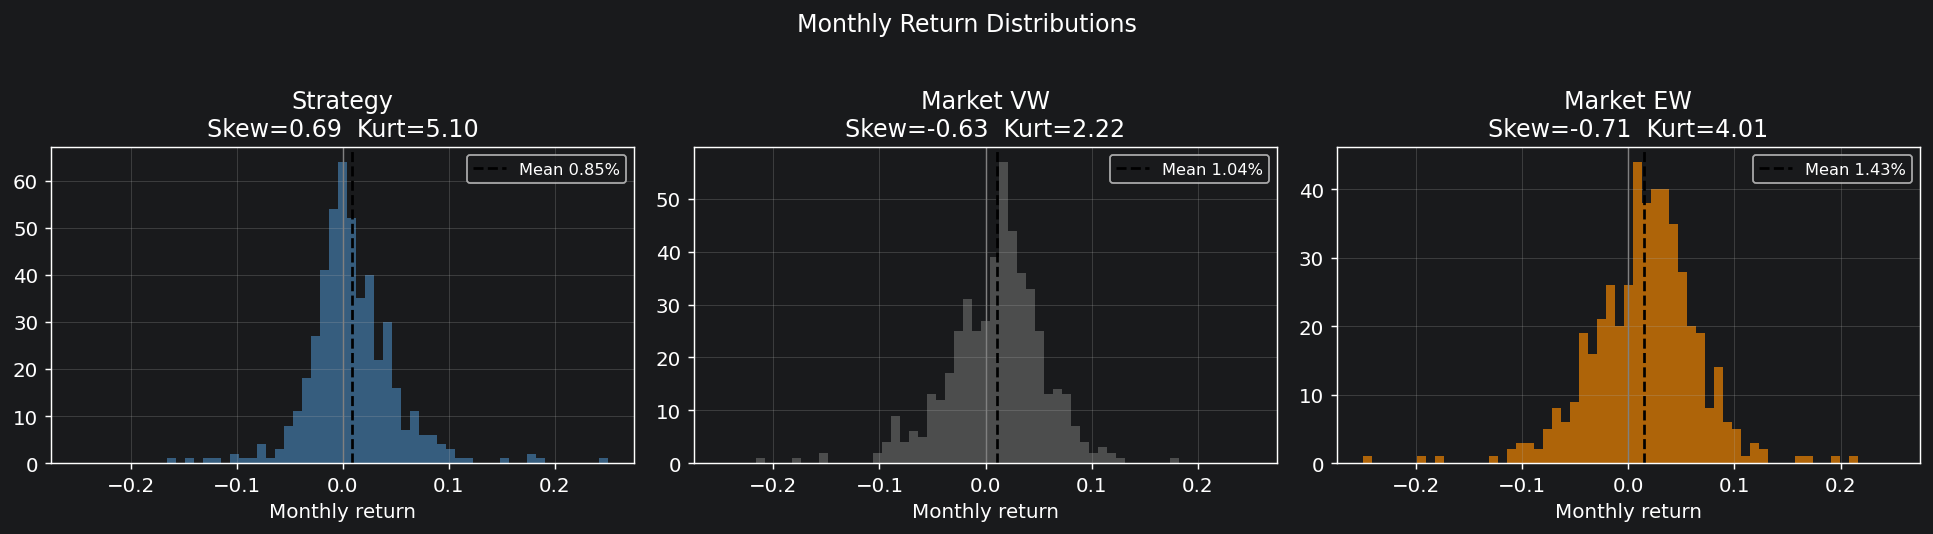

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
data = [(strat, "Strategy", STRAT_COLOR), (vw, "Market VW", VW_COLOR), (ew, "Market EW", EW_COLOR)]
bins = np.linspace(-0.25, 0.25, 60)

for ax, (s, label, col) in zip(axes, data):
    s = s.dropna()
    ax.hist(s, bins=bins, color=col, alpha=0.65)
    ax.axvline(s.mean(), color="black", lw=1.5, ls="--", label=f"Mean {s.mean():.2%}")
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(f"{label}\nSkew={s.skew():.2f}  Kurt={s.kurt():.2f}")
    ax.set_xlabel("Monthly return")
    ax.legend(fontsize=9)

fig.suptitle("Monthly Return Distributions", y=1.02)
fig.tight_layout()
plt.show()

## 9 · Turnover & Transaction Costs

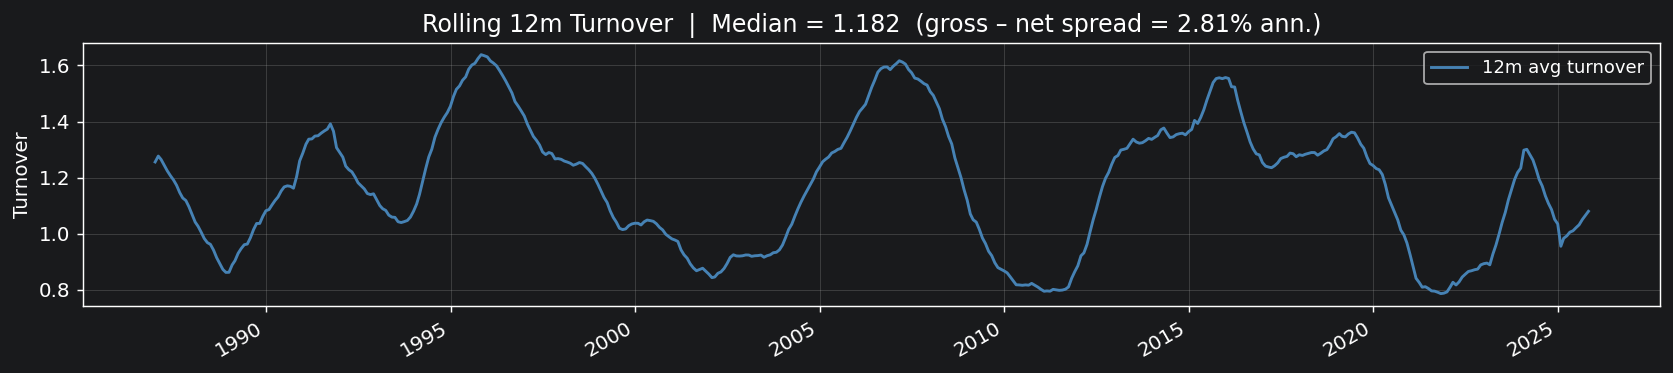

Gross Sharpe: 0.921   Net Sharpe: 0.722   TC drag: 0.199


In [11]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(C.index, C["turnover"].rolling(12).mean(), color=STRAT_COLOR, lw=1.6, label="12m avg turnover")
ax.set_ylabel("Turnover")
ax.set_title(f"Rolling 12m Turnover  |  Median = {C['turnover'].median():.3f}  "
             f"(gross – net spread = {(C['qspread'] - C['net_qspread']).mean()*12:.2%} ann.)")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

gross_sr = C["qspread"].mean() / C["qspread"].std() * np.sqrt(12)
net_sr   = C["net_qspread"].mean() / C["net_qspread"].std() * np.sqrt(12)
print(f"Gross Sharpe: {gross_sr:.3f}   Net Sharpe: {net_sr:.3f}   TC drag: {gross_sr - net_sr:.3f}")

## 10 · Long / Short Leg Breakdown

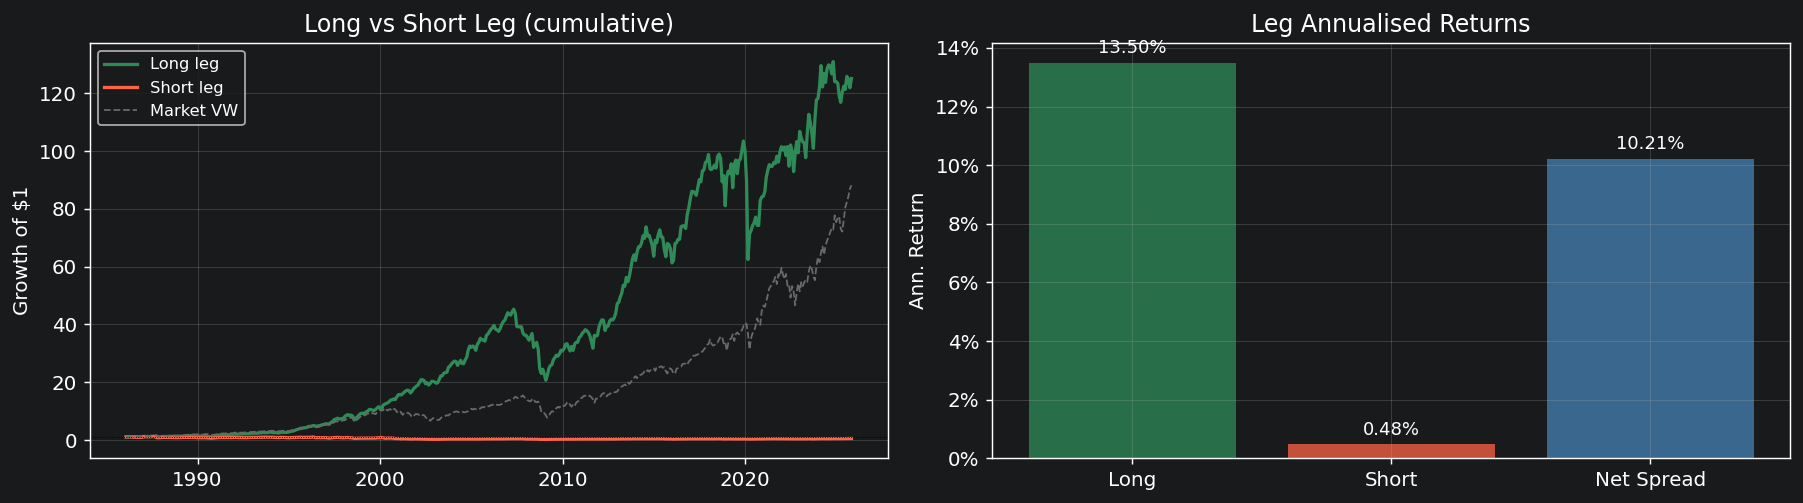

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# cumulative long vs short
ax = axes[0]
ax.plot((1 + C["long_ret"].dropna()).cumprod(),  label="Long leg",  lw=1.8, color="seagreen")
ax.plot((1 + C["short_ret"].dropna()).cumprod(), label="Short leg", lw=1.8, color="tomato")
ax.plot(cum(vw), label="Market VW", lw=1.0, color=VW_COLOR, ls="--")
ax.axhline(1, color="black", lw=0.5, ls=":")
ax.set_ylabel("Growth of $1")
ax.set_title("Long vs Short Leg (cumulative)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(10))

# leg return stats
ax = axes[1]
long_a  = C["long_ret"].mean()  * 12
short_a = C["short_ret"].mean() * 12
spread  = C["net_qspread"].mean() * 12
bars = ax.bar(["Long", "Short", "Net Spread"],
              [long_a, short_a, spread],
              color=["seagreen", "tomato", STRAT_COLOR], alpha=0.75)
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("Ann. Return")
ax.set_title("Leg Annualised Returns")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for bar, val in zip(bars, [long_a, short_a, spread]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002 * np.sign(val),
            f"{val:.2%}", ha="center", va="bottom" if val >= 0 else "top", fontsize=10)

fig.tight_layout()
plt.show()